In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Supervised Learning/Churn_predication_project/telecom_churn_rows_243553-14.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [63]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [64]:
df.shape

(243553, 14)

In [65]:
df.isnull().sum()

,0
customer_id,0
telecom_partner,0
gender,0
age,0
state,0
city,0
pincode,0
date_of_registration,0
num_dependents,0
estimated_salary,0


In [66]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [67]:
# drop customer id column

df = df.drop("customer_id",axis=1)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   telecom_partner       243553 non-null  object
 1   gender                243553 non-null  object
 2   age                   243553 non-null  int64 
 3   state                 243553 non-null  object
 4   city                  243553 non-null  object
 5   pincode               243553 non-null  int64 
 6   date_of_registration  243553 non-null  object
 7   num_dependents        243553 non-null  int64 
 8   estimated_salary      243553 non-null  int64 
 9   calls_made            243553 non-null  int64 
 10  sms_sent              243553 non-null  int64 
 11  data_used             243553 non-null  int64 
 12  churn                 243553 non-null  int64 
dtypes: int64(8), object(5)
memory usage: 24.2+ MB


In [69]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns
drop_cols=['date_of_registration','state','city']
categorical_cols = categorical_cols.drop(drop_cols)
print(categorical_cols)
print(numerical_cols)

Index(['telecom_partner', 'gender'], dtype='object')
Index(['age', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made',
       'sms_sent', 'data_used', 'churn'],
      dtype='object')


# data analyze

churn
0    194726
1     48827
Name: count, dtype: int64


Text(0.5, 1.0, 'Is churn yes or not ?')

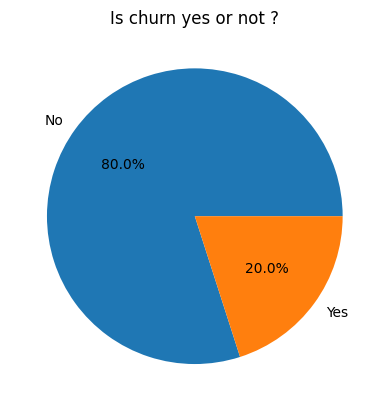

In [70]:
# how the balance classes are ?
classes_count = df['churn'].value_counts()
print(classes_count)

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is churn yes or not ?")

In [71]:
for i in categorical_cols:
  print(df[i].value_counts())
  print("-------------------------------")


telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64
-------------------------------
gender
M    145977
F     97576
Name: count, dtype: int64
-------------------------------


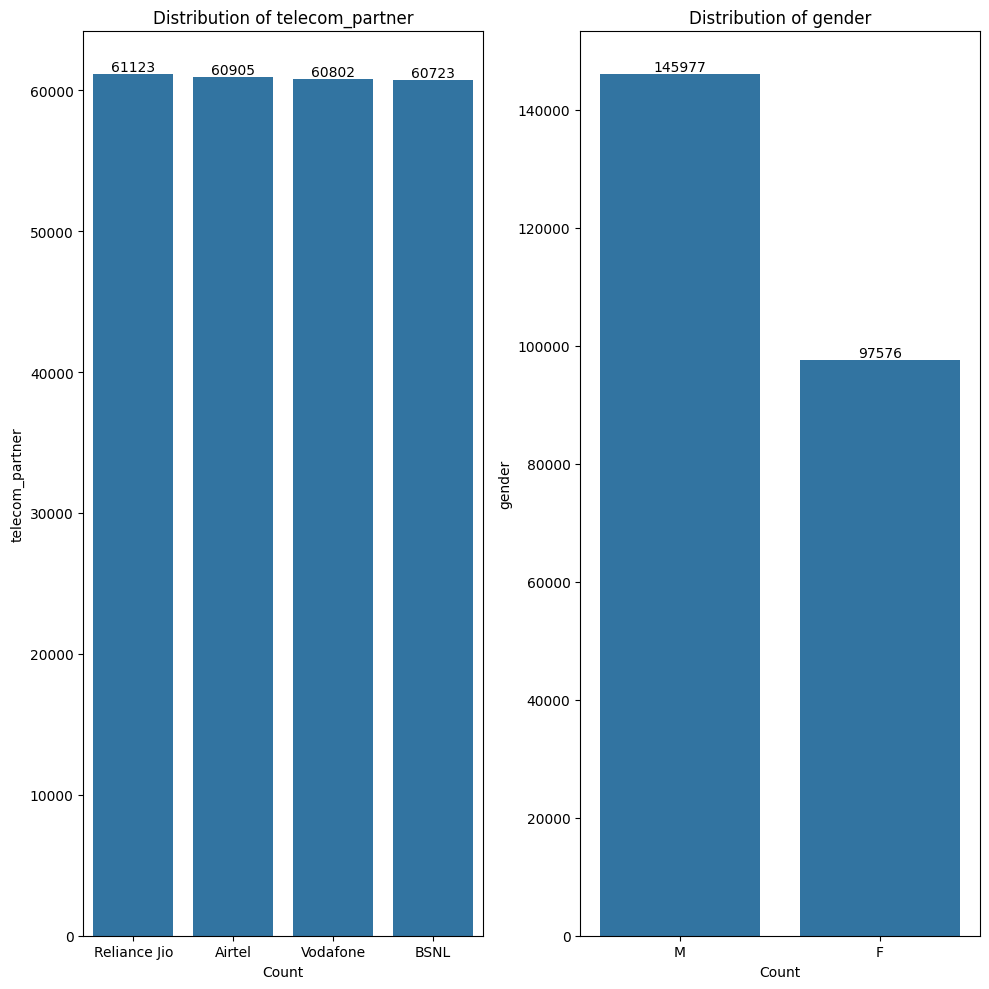

In [72]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 10)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    counts = df[col].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

    axes[i].bar_label(axes[i].containers[0])

plt.tight_layout()
plt.show()

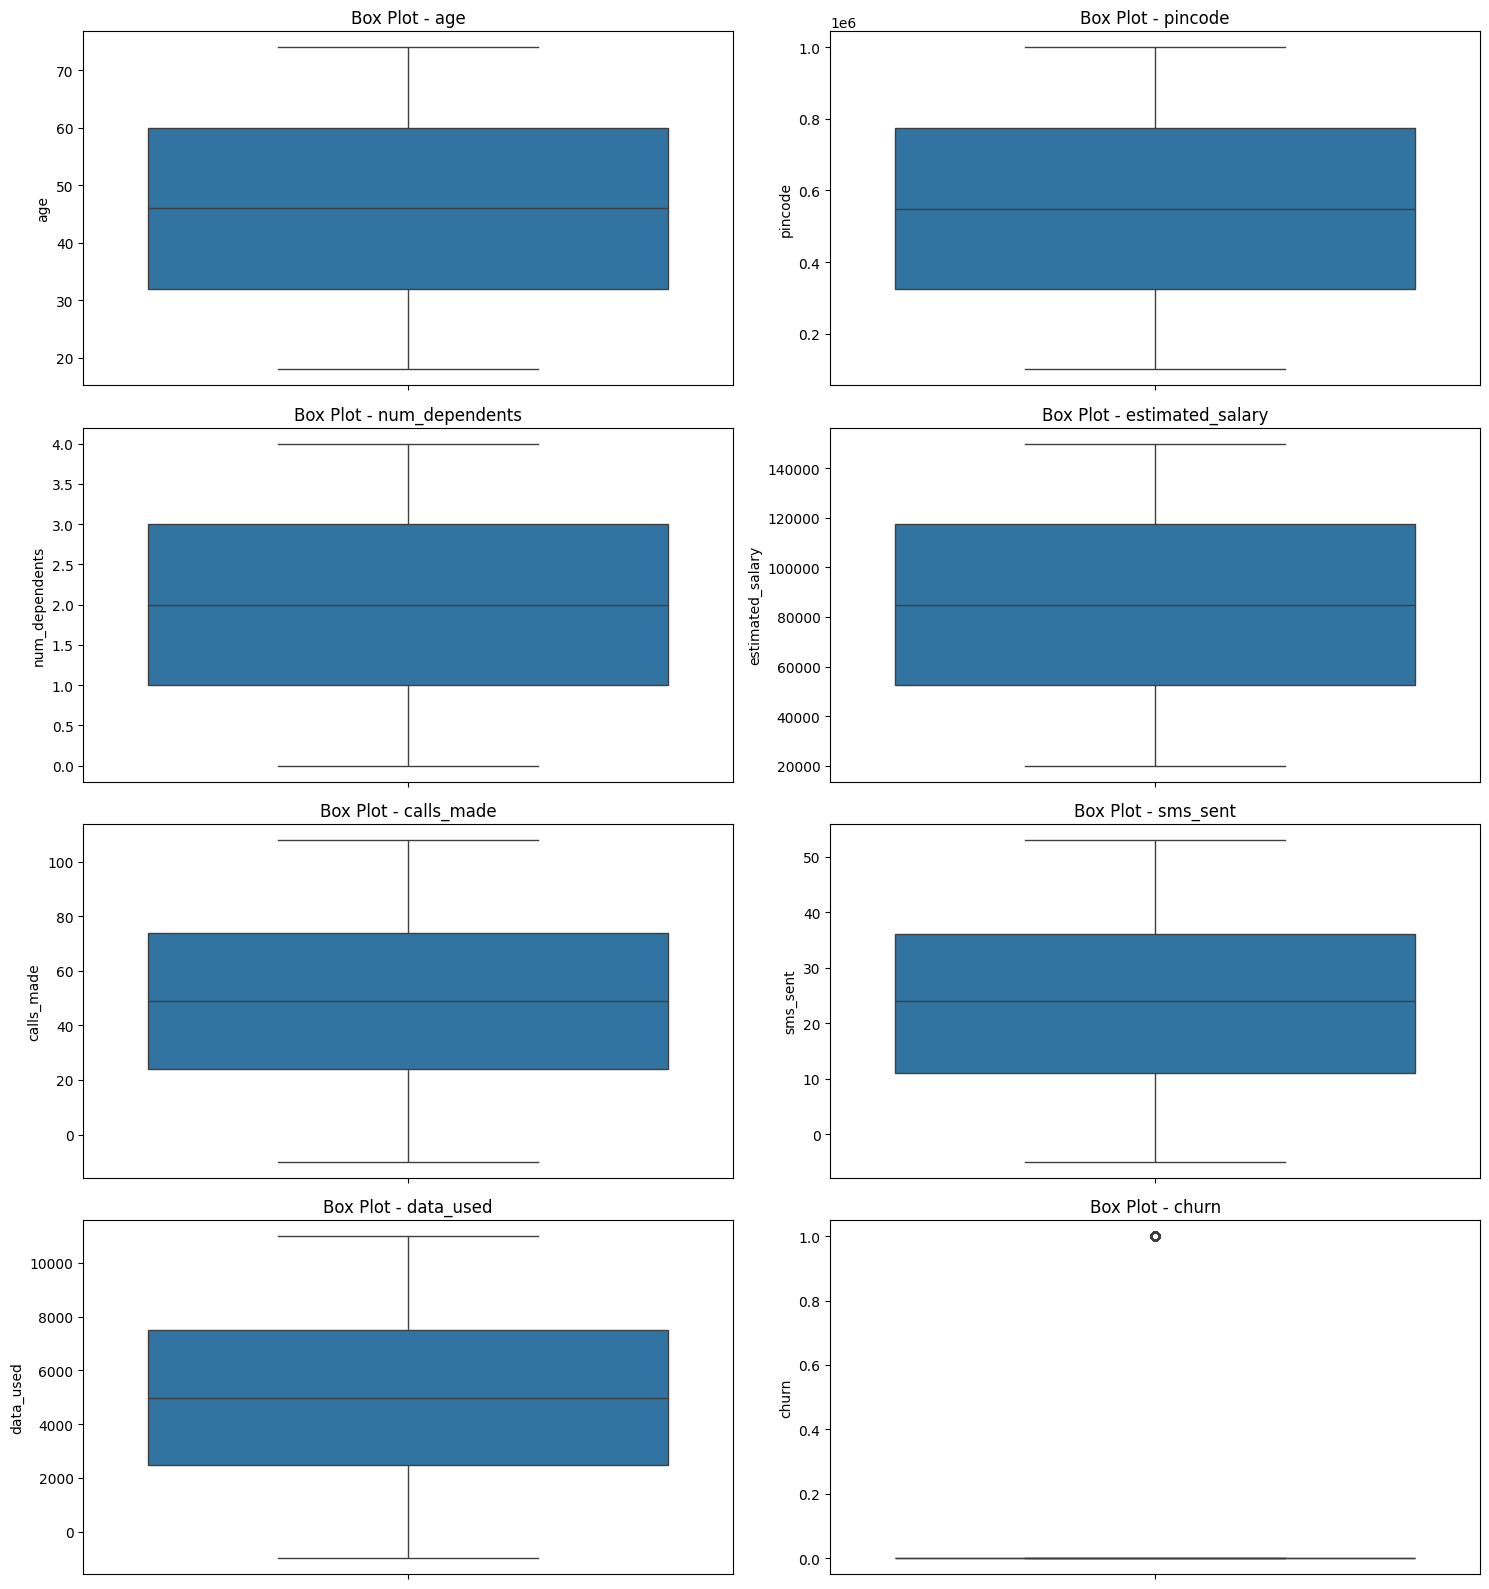

In [73]:
# check outliers in numerical columns
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(15, 16)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Box Plot - {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Encoding (Feature Encoding)

In [74]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [75]:
for i in categorical_cols:
  print(df[i].value_counts())
  print("-------------------------------")


telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64
-------------------------------
gender
M    145977
F     97576
Name: count, dtype: int64
-------------------------------


In [76]:
print(categorical_cols.values)

['telecom_partner' 'gender']


In [77]:
# for OneHotEncoding
nominal_cols = ['telecom_partner','gender']

#for LabelEncoding
# ordinal_cols = [] this is empty list

In [78]:
# le = LabelEncoder()

# for col in ordinal_cols:
#   df[col] = le.fit_transform(df[col])

In [79]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded_array = ohe.fit_transform(df[nominal_cols]) #here return nd array

encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(nominal_cols), index=df.index)

df = df.drop(nominal_cols, axis=1) # drop a previous columns

df = pd.concat([df, encoded_df], axis=1) # concatination old dataset to new dataframes

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           243553 non-null  int64  
 1   state                         243553 non-null  object 
 2   city                          243553 non-null  object 
 3   pincode                       243553 non-null  int64  
 4   date_of_registration          243553 non-null  object 
 5   num_dependents                243553 non-null  int64  
 6   estimated_salary              243553 non-null  int64  
 7   calls_made                    243553 non-null  int64  
 8   sms_sent                      243553 non-null  int64  
 9   data_used                     243553 non-null  int64  
 10  churn                         243553 non-null  int64  
 11  telecom_partner_BSNL          243553 non-null  float64
 12  telecom_partner_Reliance Jio  243553 non-nul

# train & test split

In [81]:
# less_relavant_cols = ['StreamingTV_Yes','StreamingMovies_Yes','MultipleLines_Yes','PhoneService_Yes','gender_Male','MultipleLines_No phone service','DeviceProtection_Yes','OnlineBackup_Yes','PaymentMethod_Mailed check']
# most_relavant_cols = ['Contract','tenure','InternetService_Fiber optic']

In [82]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [83]:
# for i in most_relavant_cols:
#   df[i] = df[i] ** 2

X = df.drop("churn",axis=1)
X = X.drop(drop_cols,axis=1)
y=df['churn']

print(X.shape)
print(y.shape)

(243553, 11)
(243553,)


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(X_train.shape)
print(X_test.shape)

(121776, 11)
(121777, 11)


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<Axes: >

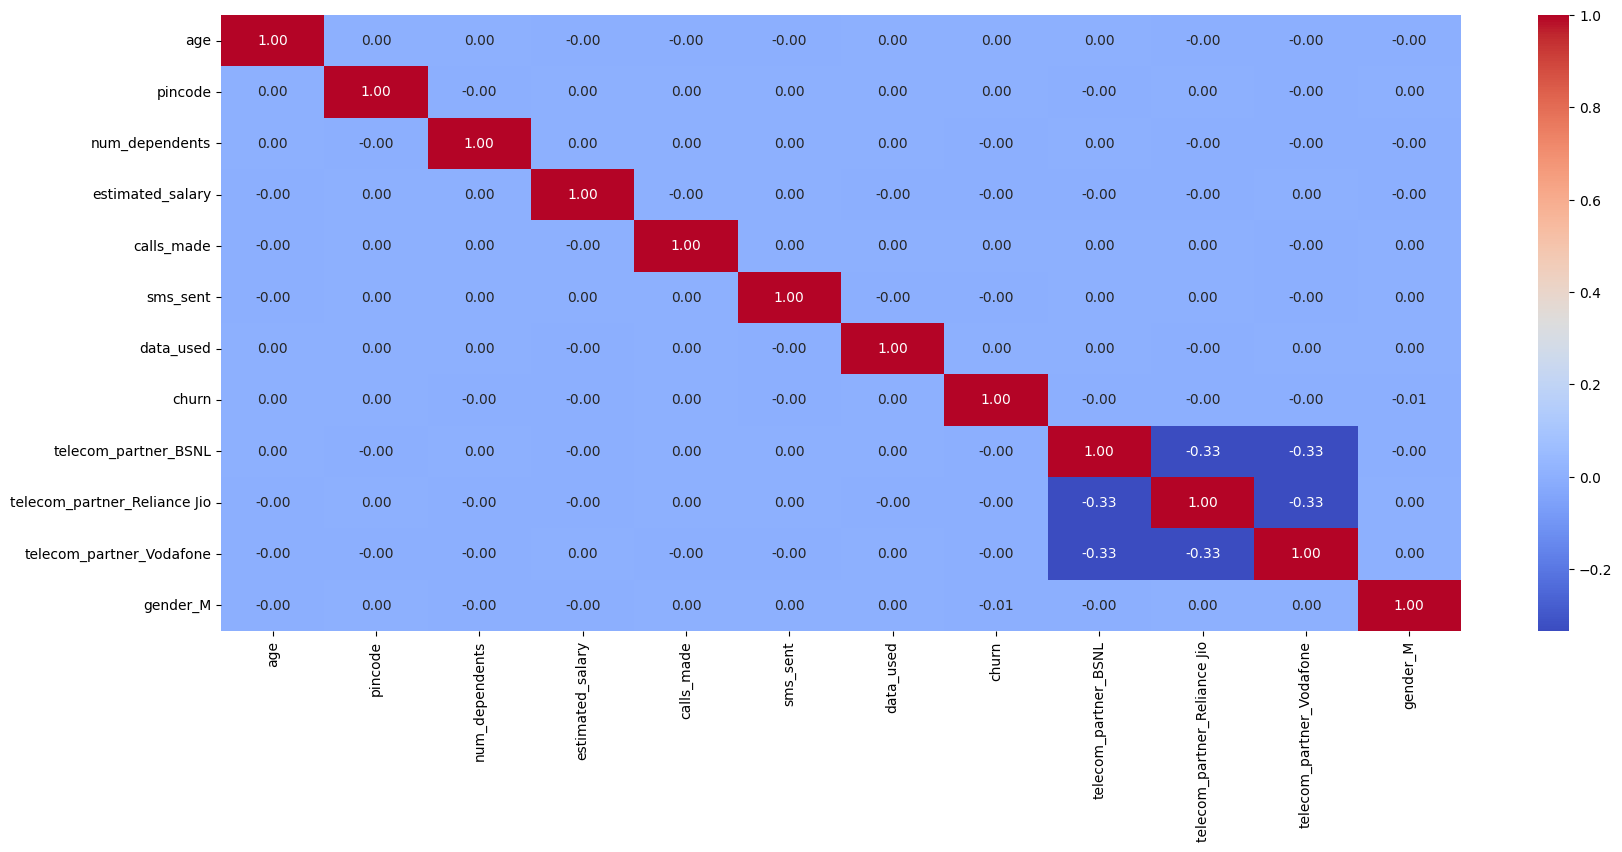

In [86]:
num_cols = df.select_dtypes(include="number")

corr_matrix = num_cols.corr()

# print(corr_matrix)
plt.figure(figsize=(20, 8))
sns.heatmap(
  corr_matrix,
  annot= True,
  fmt=".2f",
  cmap="coolwarm"
)

In [87]:
num_cols.corr()["churn"].sort_values(ascending = False)



,churn
churn,1.000000
calls_made,0.001692
pincode,0.001019
age,0.000839
data_used,0.000732
telecom_partner_Reliance Jio,-0.000469
telecom_partner_Vodafone,-0.001433
num_dependents,-0.002543
telecom_partner_BSNL,-0.002693
sms_sent,-0.003072


# Train && Evaluate Model

In [88]:
#  logistic regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)


In [89]:
# KNN classification
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier()
param_grid = {"n_neighbors" : [3, 5, 7, 9, 11, 13, 15, 17]}

classifierCV = GridSearchCV(
    knn_classifier,
    param_grid,
    cv=7,
    scoring="recall"
)

knn_classifier.fit(X_train, y_train)

knn_pred = knn_classifier.predict(X_test)

In [90]:
# Naive Bayes classification

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [91]:
# decision Tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6,min_samples_split=25)
dt_model.fit(X_train, y_train)

dt_y_pred = dt_model.predict(X_test)

In [92]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=20, random_state=42)

rf_classifier.fit(X_train, y_train)

rf_y_pred = rf_classifier.predict(X_test)

In [93]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

print("Logistic Regression Metrics:")
print("Precision : ",precision_score(y_test, log_pred))
print("Recall : ",recall_score(y_test, log_pred))
print("Accuracy : ",accuracy_score(y_test, log_pred))
print("CM :", confusion_matrix(y_test, log_pred))

print("\n-----------------------------------------------------------\n")
print("KNN Classification Metrics:")
print("Precision : ",precision_score(y_test, knn_pred))
print("Recall : ",recall_score(y_test, knn_pred))
print("Accuracy : ",accuracy_score(y_test, knn_pred))
print("CM :", confusion_matrix(y_test, knn_pred))

print("\n-----------------------------------------------------------\n")
print("Naive Bayes Classification Metrics:")
print("Precision : ",precision_score(y_test, nb_pred))
print("Recall : ",recall_score(y_test, nb_pred))
print("Accuracy : ",accuracy_score(y_test, nb_pred))
print("CM :", confusion_matrix(y_test, nb_pred))

print("\n-----------------------------------------------------------\n")
print("Decision Tree Classification Metrics:")
print("Precision : ",precision_score(y_test, dt_y_pred))
print("Recall : ",recall_score(y_test, dt_y_pred))
print("Accuracy : ",accuracy_score(y_test, dt_y_pred))
print("CM :", confusion_matrix(y_test, dt_y_pred))

print("\n---------------------------------------------------------")
print("Random Forest Classification Metrics:")
print("Precision : ",precision_score(y_test, rf_y_pred))
print("Recall : ",recall_score(y_test, rf_y_pred))
print("Accuracy : ",accuracy_score(y_test, rf_y_pred))
print("CM :", confusion_matrix(y_test, rf_y_pred))

Logistic Regression Metrics:
Precision :  0.0
Recall :  0.0
Accuracy :  0.7988700657759675
CM : [[97284     0]
 [24493     0]]

-----------------------------------------------------------

KNN Classification Metrics:
Precision :  0.19465866895172806
Recall :  0.05564855264769526
Accuracy :  0.7637567028256568
CM : [[91645  5639]
 [23130  1363]]

-----------------------------------------------------------

Naive Bayes Classification Metrics:
Precision :  0.0
Recall :  0.0
Accuracy :  0.7988700657759675
CM : [[97284     0]
 [24493     0]]

-----------------------------------------------------------

Decision Tree Classification Metrics:
Precision :  0.1702127659574468
Recall :  0.0006532478667374352
Accuracy :  0.7983609384366506
CM : [[97206    78]
 [24477    16]]

---------------------------------------------------------
Random Forest Classification Metrics:
Precision :  0.19806763285024154
Recall :  0.0033478953170293555
Accuracy :  0.7968171329561411
CM : [[96952   332]
 [24411    82

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


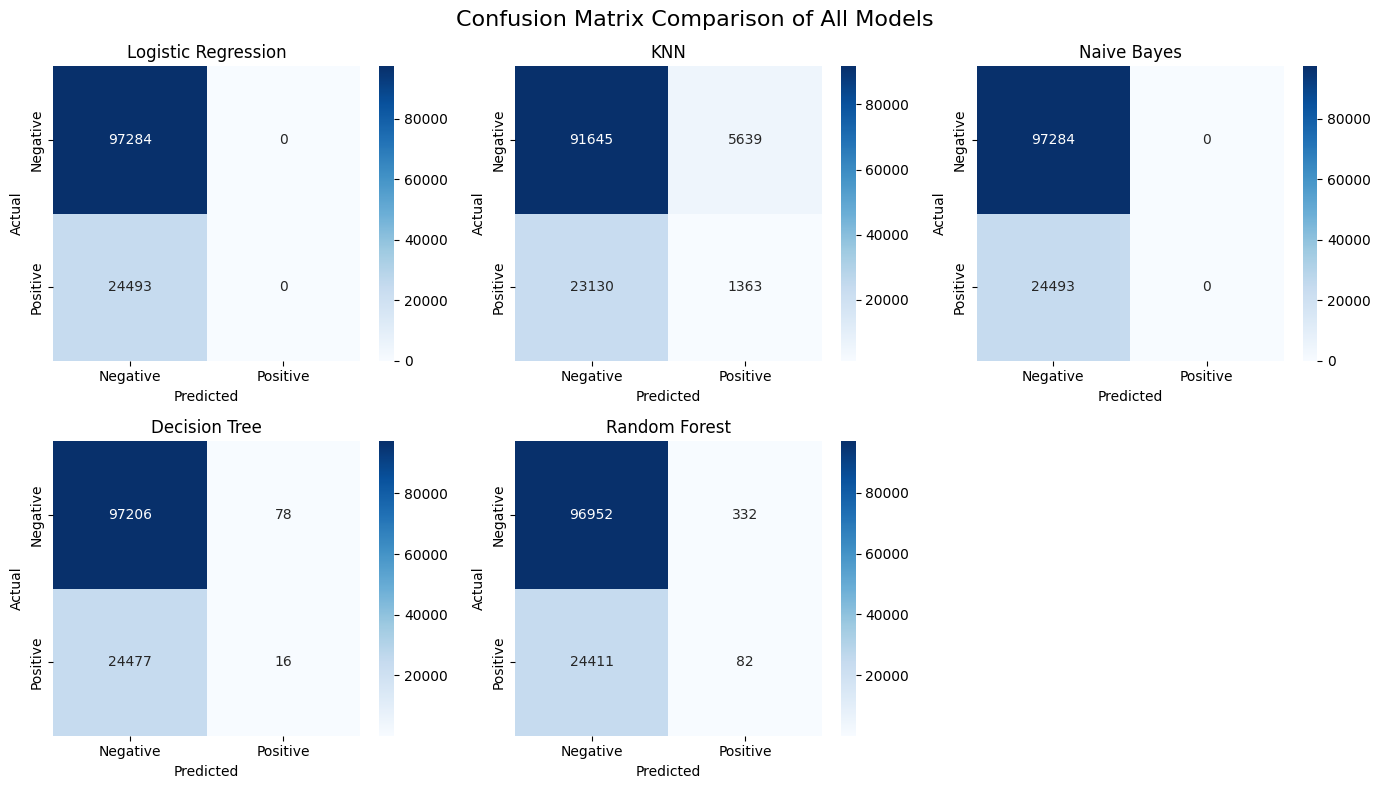

In [94]:

# Store model names and predictions
models = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_y_pred,
    "Random Forest": rf_y_pred
}

# Create one figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Flatten axes so we can loop easily
axes = axes.flatten()

for ax, (name, pred) in zip(axes, models.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide the unused 6th subplot
axes[5].axis("off")

plt.suptitle("Confusion Matrix Comparison of All Models", fontsize=16)
plt.tight_layout()
plt.show()